# Species Statistics — Stirred Tank Reactive LBM

Two-step catalytic reaction: **S + C → I → P + C**

- `mean_rho_S/C/I/P`: volume-averaged LB density of each species
- `cat_cycle_sum = ρ_C + ρ_I` — conserved after catalyst injection (step 377 000)
- `sub_cycle_sum = ρ_S + ρ_I + ρ_P` — conserved at all times

## 1. Import Required Libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## 2. Load and Inspect the CSV Data

In [23]:
CSV_OLD      = "/kfs3/scratch/nsawant/movingBody/marblesThermal/Build/run1/species_stats.csv"   # clamp=1
CSV_SPILL    = "/kfs3/scratch/nsawant/movingBody/marblesThermal/Build/run2/species_stats.csv"   # clamp=0 + spill fix
CSV_NEW      = "/kfs3/scratch/nsawant/movingBody/marblesThermal/Build/species_stats.csv"        # clamp=0 + spill fix + entropic

def load_csv(path):
    df = pd.read_csv(path, sep=r"\s+", engine="python")
    df.columns = df.columns.str.strip()
    return df

df_old   = load_csv(CSV_OLD)
df_spill = load_csv(CSV_SPILL)
df_new   = load_csv(CSV_NEW)

for label, df in [("clamp=1 (run1)", df_old),
                  ("spill fix (run2)", df_spill),
                  ("entropic (new)", df_new)]:
    print(f"{label:25s}: {len(df):,} rows,  last step = {int(df['step'].max()):,}")
print("Columns:", df_old.columns.tolist())


clamp=1 (run1)           : 1,800,000 rows,  last step = 1,800,000
spill fix (run2)         : 1,800,000 rows,  last step = 1,800,000
entropic (new)           : 1,785,093 rows,  last step = 1,785,093
Columns: ['step', 'LBtime', 'mean_rho_S', 'mean_rho_C', 'mean_rho_I', 'mean_rho_P', 'cat_cycle_sum', 'sub_cycle_sum']


## 3. Convert Step Index to Physical Time

In [24]:
DT_PHYS         = 1.326e-5   # s / step
CAT_INJECT_STEP = 377_000
C_REF           = 500.0      # (mol/L) per LB_rho unit
CYL_CORRECTION  = 4.0 / np.pi  # cubic→cylindrical volume correction

def process(df):
    df = df.copy()
    df["t_phys"] = df["step"] * DT_PHYS
    for sp in ["S", "C", "I", "P"]:
        df[f"conc_{sp}"]     = df[f"mean_rho_{sp}"] * C_REF
        df[f"conc_{sp}_cyl"] = df[f"conc_{sp}"] * CYL_CORRECTION
    rho_S0 = df.loc[df["step"] == df["step"].min(), "mean_rho_S"].values[0]
    df["X_S"] = 1.0 - df["mean_rho_S"] / rho_S0
    df["Y_P"] = df["mean_rho_P"] / rho_S0
    df["f_I"] = df["mean_rho_I"] / rho_S0
    return df, rho_S0

df_old,   rho_S0_old   = process(df_old)
df_spill, rho_S0_spill = process(df_spill)
df_new,   rho_S0_new   = process(df_new)

t_cat = CAT_INJECT_STEP * DT_PHYS
print(f"Catalyst injection : {t_cat:.3f} s  (step {CAT_INJECT_STEP:,})")
print(f"CYL correction     : 4/π = {CYL_CORRECTION:.4f}")
print()
for label, df, rho_S0 in [("clamp=1 (run1)",   df_old,   rho_S0_old),
                           ("spill fix (run2)", df_spill, rho_S0_spill),
                           ("entropic (new)",   df_new,   rho_S0_new)]:
    c0 = rho_S0 * C_REF * CYL_CORRECTION
    tend = df["t_phys"].max()
    print(f"{label:25s}: t_end={tend:.2f} s,  initial [S]_cyl={c0*1e3:.2f} mmol/L")


Catalyst injection : 4.999 s  (step 377,000)
CYL correction     : 4/π = 1.2732

clamp=1 (run1)           : t_end=23.87 s,  initial [S]_cyl=8.19 mmol/L
spill fix (run2)         : t_end=23.87 s,  initial [S]_cyl=8.19 mmol/L
entropic (new)           : t_end=23.67 s,  initial [S]_cyl=8.19 mmol/L


## 4. Species Volume-Averaged Densities vs Physical Time

/tmp/ipykernel_814638/2590222547.py:37: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()


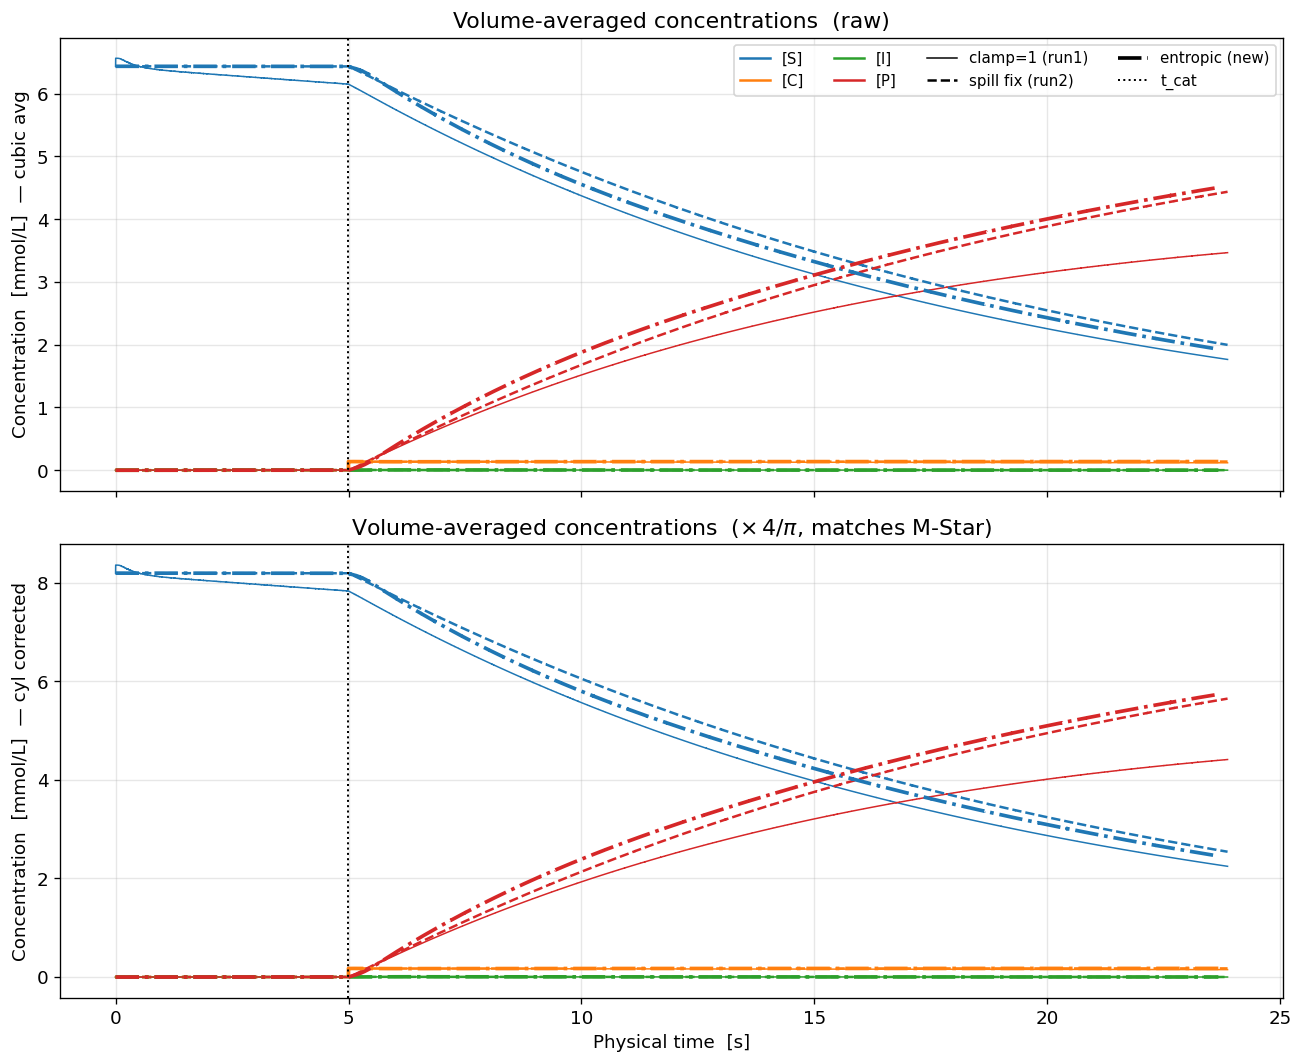

In [25]:
colors = {"S": "#1f77b4", "C": "#ff7f0e", "I": "#2ca02c", "P": "#d62728"}
runs = [
    (df_old,   "clamp=1 (run1)",   "-",    0.9),
    (df_spill, "spill fix (run2)", "--",   1.5),
    (df_new,   "entropic (new)",   "-.",   2.2),
]

fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True)

for ax_idx, (ylabel, col_suffix) in enumerate([
        ("Concentration  [mmol/L]  — cubic avg",     "conc_{}"),
        ("Concentration  [mmol/L]  — cyl corrected", "conc_{}_cyl"),
]):
    ax = axes[ax_idx]
    for df, run_label, ls, lw in runs:
        for sp, col in colors.items():
            key = col_suffix.format(sp)
            ax.plot(df["t_phys"], df[key] * 1e3,
                    color=col, ls=ls, lw=lw)
    ax.axvline(t_cat, color="k", ls=":", lw=1.2)
    ax.set_ylabel(ylabel)
    title_suffix = "(raw)" if ax_idx == 0 else r"($\times\,4/\pi$, matches benchmark)"
    ax.set_title(f"Volume-averaged concentrations  {title_suffix}")
    ax.grid(alpha=0.3)

from matplotlib.lines import Line2D
legend_handles  = [Line2D([0],[0], color=col, lw=1.5, label=f"[{sp}]") for sp, col in colors.items()]
legend_handles += [
    Line2D([0],[0], color="k", ls="-",   lw=0.9, label="clamp=1 (run1)"),
    Line2D([0],[0], color="k", ls="--",  lw=1.5, label="spill fix (run2)"),
    Line2D([0],[0], color="k", ls="-.",  lw=2.2, label="entropic (new)"),
    Line2D([0],[0], color="k", ls=":",   lw=1.2, label="t_cat"),
]
axes[0].legend(handles=legend_handles, ncol=4, fontsize=9)
axes[1].set_xlabel("Physical time  [s]")

fig.tight_layout()
plt.savefig("species_densities.png", dpi=150, bbox_inches="tight")
plt.show()


## 4b. Species Concentrations — Current Run Only (entropic)

/tmp/ipykernel_814638/3571516011.py:22: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()


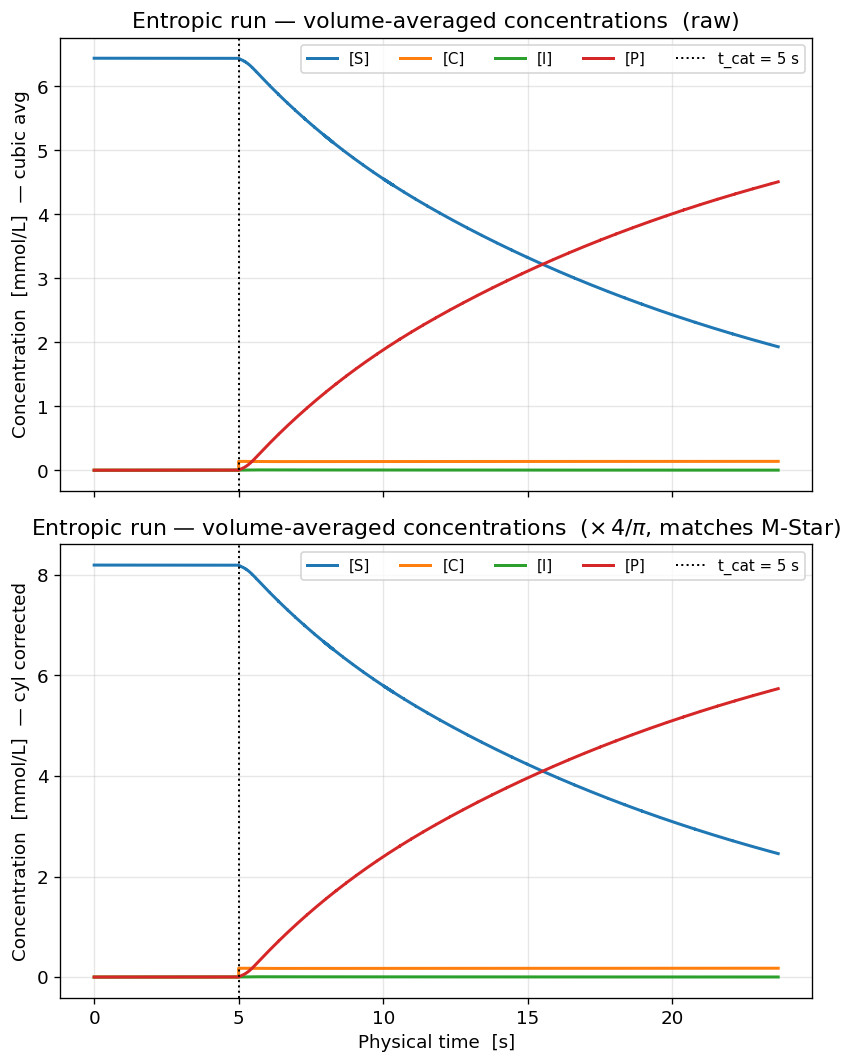

In [26]:
colors = {"S": "#1f77b4", "C": "#ff7f0e", "I": "#2ca02c", "P": "#d62728"}

fig, axes = plt.subplots(2, 1, figsize=(7, 9), sharex=True)

for ax_idx, (ylabel, col_suffix) in enumerate([
        ("Concentration  [mmol/L]  — cubic avg",     "conc_{}"),
        ("Concentration  [mmol/L]  — cyl corrected", "conc_{}_cyl"),
]):
    ax = axes[ax_idx]
    for sp, col in colors.items():
        key = col_suffix.format(sp)
        ax.plot(df_new["t_phys"], df_new[key] * 1e3,
                color=col, lw=1.8, label=f"[{sp}]")
    ax.axvline(t_cat, color="k", ls=":", lw=1.2, label="t_cat = 5 s")
    ax.set_ylabel(ylabel)
    title_suffix = "(raw)" if ax_idx == 0 else r"($\times\,4/\pi$, matches benchmark)"
    ax.set_title(f"Entropic run — volume-averaged concentrations  {title_suffix}")
    ax.legend(ncol=5, fontsize=9)
    ax.grid(alpha=0.3)

axes[1].set_xlabel("Physical time  [s]")
fig.tight_layout()
plt.savefig("species_densities_entropic.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Conservation Law Verification

Expected:
- **Catalyst balance** `ρ_C + ρ_I = const` after step 377 000  →  `cat_cycle_sum`
- **Substrate balance** `ρ_S + ρ_I + ρ_P = const` at *all* times  →  `sub_cycle_sum`

The CSV already records both sums directly. We plot the absolute and relative deviation from their post-injection values.

clamp=1 (run1):
  Max |Δ(S+I+P)| / ref = 1.870e+01 %
  Max |Δ(C+I)|   / ref = inf %

spill fix (run2):
  Max |Δ(S+I+P)| / ref = 2.052e-02 %
  Max |Δ(C+I)|   / ref = inf %

entropic (new):
  Max |Δ(S+I+P)| / ref = 2.448e-02 %
  Max |Δ(C+I)|   / ref = inf %



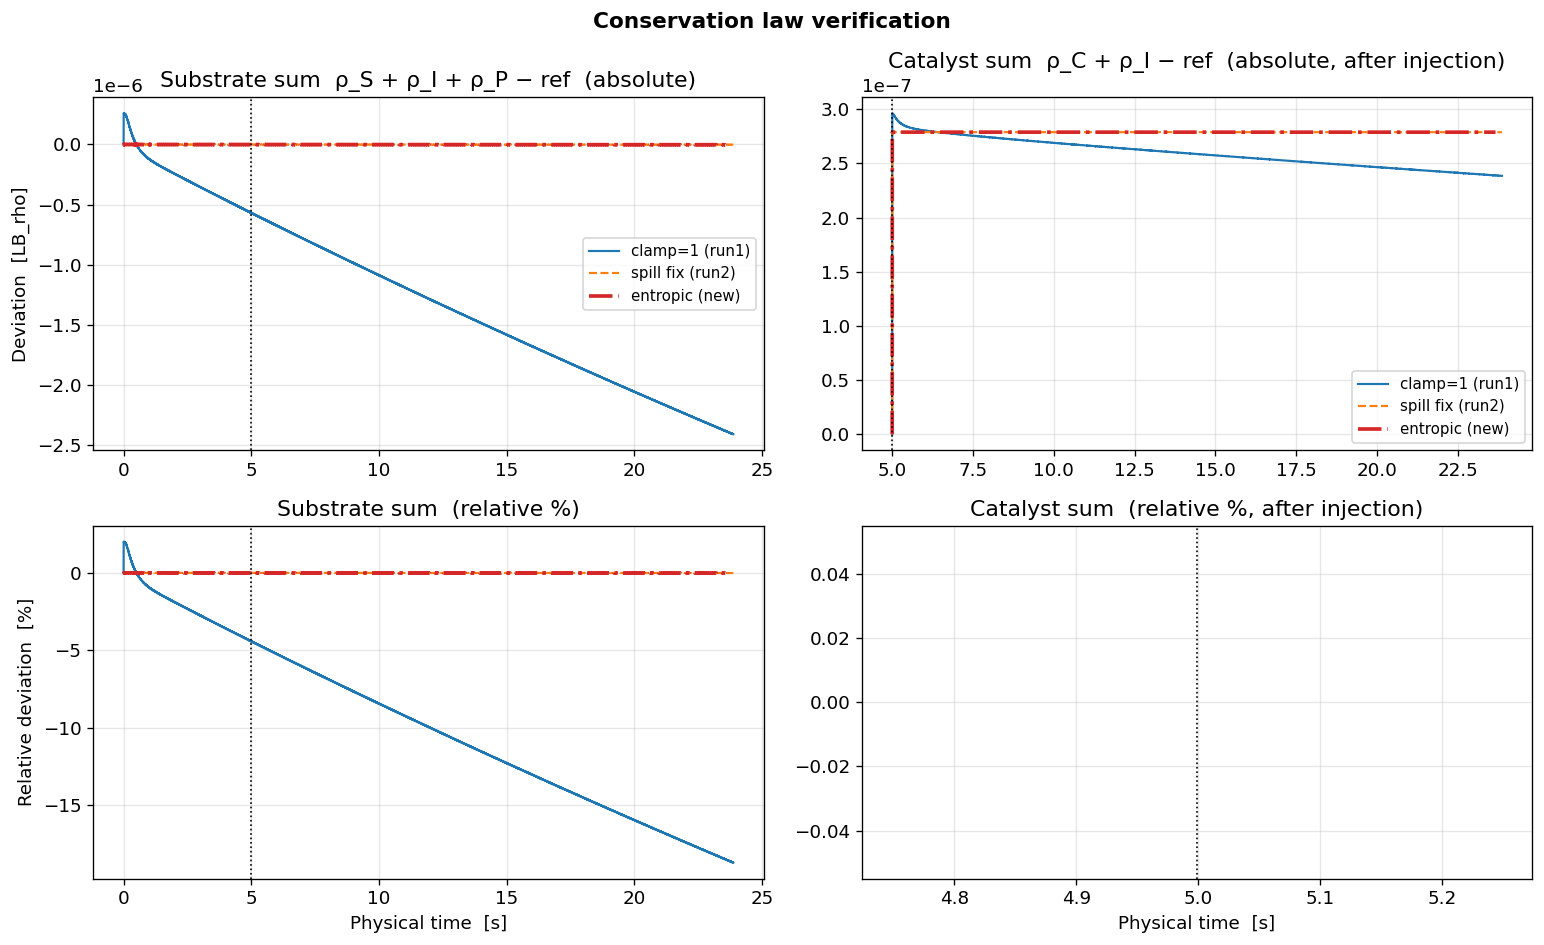

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=False)

run_styles = [
    (df_old,   "clamp=1 (run1)",   "#1f77b4", "-"),
    (df_spill, "spill fix (run2)", "#ff7f0e", "--"),
    (df_new,   "entropic (new)",   "#d62728", "-."),
]

for df, label, col, ls in run_styles:
    lw = 2.2 if ls == "-." else 1.3
    post_cat = df[df["step"] >= CAT_INJECT_STEP]
    ref_sub  = df["sub_cycle_sum"].iloc[0]
    ref_cat  = post_cat["cat_cycle_sum"].iloc[0] if len(post_cat) else np.nan

    rel_sub = (df["sub_cycle_sum"] - ref_sub) / ref_sub * 100
    rel_cat = (post_cat["cat_cycle_sum"] - ref_cat) / ref_cat * 100 \
              if not np.isnan(ref_cat) else post_cat["cat_cycle_sum"] * 0

    axes[0, 0].plot(df["t_phys"], df["sub_cycle_sum"] - ref_sub,
                    color=col, ls=ls, lw=lw, label=label)
    axes[0, 1].plot(post_cat["t_phys"], post_cat["cat_cycle_sum"] - ref_cat,
                    color=col, ls=ls, lw=lw, label=label)
    axes[1, 0].plot(df["t_phys"], rel_sub, color=col, ls=ls, lw=lw)
    axes[1, 1].plot(post_cat["t_phys"], rel_cat, color=col, ls=ls, lw=lw)

    print(f"{label}:")
    print(f"  Max |Δ(S+I+P)| / ref = {rel_sub.abs().max():.3e} %")
    if not np.isnan(ref_cat):
        print(f"  Max |Δ(C+I)|   / ref = {rel_cat.abs().max():.3e} %")
    print()

for ax in axes.flat:
    ax.axvline(t_cat, color="k", ls=":", lw=1)
    ax.grid(alpha=0.3)

axes[0, 0].set_title("Substrate sum  ρ_S + ρ_I + ρ_P − ref  (absolute)")
axes[0, 1].set_title("Catalyst sum  ρ_C + ρ_I − ref  (absolute, after injection)")
axes[1, 0].set_title("Substrate sum  (relative %)")
axes[1, 1].set_title("Catalyst sum  (relative %, after injection)")
axes[0, 0].set_ylabel("Deviation  [LB_rho]")
axes[1, 0].set_ylabel("Relative deviation  [%]")
axes[1, 0].set_xlabel("Physical time  [s]")
axes[1, 1].set_xlabel("Physical time  [s]")
axes[0, 0].legend(fontsize=9)
axes[0, 1].legend(fontsize=9)

fig.suptitle("Conservation law verification", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("conservation_check.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Reaction Progress and Yield

After catalyst injection:
- Substrate conversion: $X_S = 1 - \rho_S / \rho_{S,0}$
- Product yield: $Y_P = \rho_P / \rho_{S,0}$
- Intermediate fraction: $\rho_I / \rho_{S,0}$

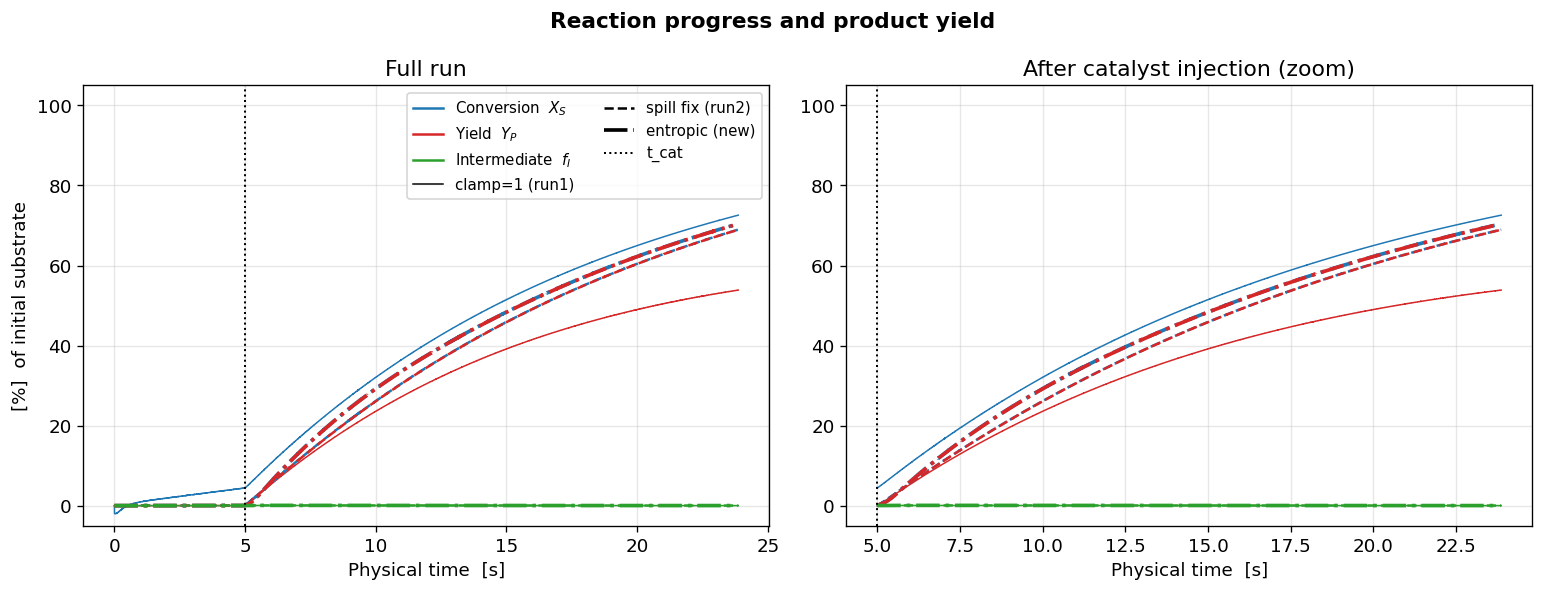

Final state comparison:
  clamp=1 (run1)           : t=23.87s  X_S=72.6%  Y_P=53.9%
  spill fix (run2)         : t=23.87s  X_S=69.0%  Y_P=68.9%
  entropic (new)           : t=23.67s  X_S=70.0%  Y_P=70.0%


In [28]:
run_styles = [
    (df_old,   "clamp=1 (run1)",   "-",    0.9),
    (df_spill, "spill fix (run2)", "--",   1.5),
    (df_new,   "entropic (new)",   "-.",   2.2),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

sp_styles = [
    ("X_S", "Conversion  $X_S$",    "#1f77b4"),
    ("Y_P", "Yield  $Y_P$",          "#d62728"),
    ("f_I", "Intermediate  $f_I$",   "#2ca02c"),
]

for ax in axes:
    for df, run_label, ls, lw in run_styles:
        data = df if ax is axes[0] else df[df["step"] >= CAT_INJECT_STEP]
        for col_key, sp_label, col in sp_styles:
            ax.plot(data["t_phys"], data[col_key] * 100,
                    color=col, ls=ls, lw=lw)
    ax.axvline(t_cat, color="k", ls=":", lw=1.2)
    ax.set_xlabel("Physical time  [s]")
    ax.set_ylim(-5, 105)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("[%]  of initial substrate")
axes[0].set_title("Full run")
axes[1].set_title("After catalyst injection (zoom)")

from matplotlib.lines import Line2D
handles  = [Line2D([0],[0], color=col, lw=1.5, label=lbl) for _, lbl, col in sp_styles]
handles += [Line2D([0],[0], color="k", ls="-",   lw=0.9, label="clamp=1 (run1)"),
            Line2D([0],[0], color="k", ls="--",  lw=1.5, label="spill fix (run2)"),
            Line2D([0],[0], color="k", ls="-.",  lw=2.2, label="entropic (new)"),
            Line2D([0],[0], color="k", ls=":",   lw=1.2, label="t_cat")]
axes[0].legend(handles=handles, fontsize=9, ncol=2)

fig.suptitle("Reaction progress and product yield", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("reaction_progress.png", dpi=150, bbox_inches="tight")
plt.show()

print("Final state comparison:")
for df, label, _, __ in run_styles:
    row = df.iloc[-1]
    print(f"  {label:25s}: t={row['t_phys']:.2f}s  X_S={row['X_S']*100:.1f}%  Y_P={row['Y_P']*100:.1f}%")
